In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [4]:
import matplotlib.pyplot as plt
from cns.process.binning import group_bins, sum_cns
from cns.utils.selection import get_cns_for_type, only_aut
from cns.display.plot import fig_lines, plot_lines
from cns.data_utils import main_load_data, select_CNS_samples, load_merged_samples, img_path, load_samples_out
import pandas as pd
from io import StringIO

In [ ]:
load_merged_samples(True);

PCAWG
Total samples: 2778
221 samples are CN neutral (below 0.00090)
16 samples have low coverage (below 0.95280)
195 samples are blacklisted
Filtered samples: 2374
TRACERx
Total samples: 1620
0 samples are CN neutral (below 0.00010)
11 samples have low coverage (below 0.87260)
286 samples do not have exact type
Filtered samples: 1330
TCGA_hg19
Total samples: 9868
848 samples are CN neutral (below 0.00030)
0 samples have low coverage (below 0.94790)
Filtered samples: 9020
Overlapping samples with PCAWG: 828
After overlap removal: 8369
Total samples: 12073


In [ ]:
# TSV string
tsv_data = """
Source \tTotal samples\tCN neutral samples\tLow coverage samples\tOther\tFiltered samples
PCAWG\t2778\t248\t13\t195\t2375
TRACERx\t1620\t1\t7\t286\t1331
TCGA\t9868\t948\t1\t828\t8275
"""

# Create DataFrame
df = pd.read_csv(StringIO(tsv_data), sep='\t')
df

,Source,Total samples,CN neutral samples,Low coverage samples,Other,Filtered samples
0,PCAWG,2778,248,13,195,2375
1,TRACERx,1620,1,7,286,1331
2,TCGA,9868,948,1,828,8275


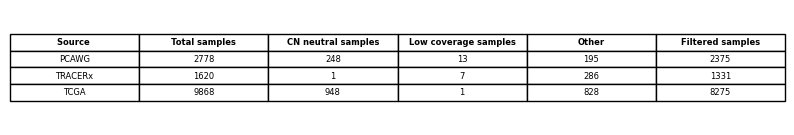

In [ ]:
fig, ax = plt.subplots(figsize=(10, 1.5))  # Set the figure size
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Make the header and index bold
for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.set_text_props(weight='bold')

# Save the plot as a PDF
plt.savefig(f"{img_path}/sample_table.pdf",  bbox_inches='tight')

# Display the plot
plt.show()

In [ ]:
tracerx_prim = load_samples_out("TRACERx_prim_samples.tsv")
print("primary", tracerx_prim.index.unique().shape[0])
tracerx_met = load_samples_out("TRACERx_met_samples.tsv")
print("metastatic", tracerx_met.index.unique().shape[0])
print("both", len(set(tracerx_prim.index.unique()) & set(tracerx_met.index.unique())))

primary 1428
metastatic 694
both 502


In [ ]:
bin_size = "3MB"
samples_df, cns_df = main_load_data(bin_size)

In [ ]:
samples_df["type"].value_counts().head(6).sum()

4852

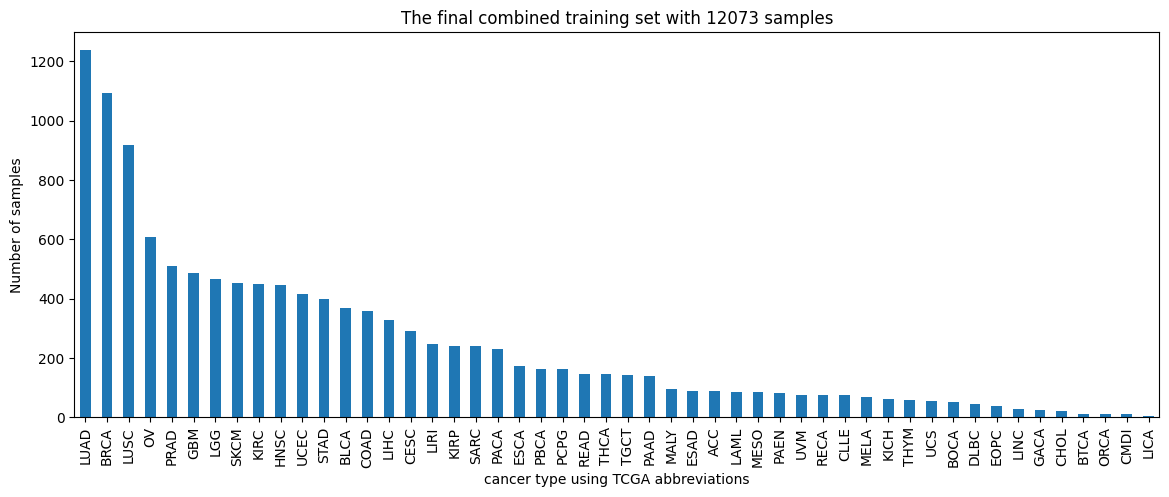

In [ ]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
plt.title("The final combined training set with {} samples".format(len(samples_df)))
plt.ylabel("Number of samples")
plt.xlabel("cancer type using TCGA abbreviations")

plt.savefig(f"{img_path}/cancer_types.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{img_path}/cancer_types.pdf", bbox_inches="tight")

In [ ]:
top_6 = samples_df["type"].value_counts().head(6).index
top_6_cns_df = [group_bins(get_cns_for_type(cns_df, samples_df, cancer_type)) for cancer_type in top_6]

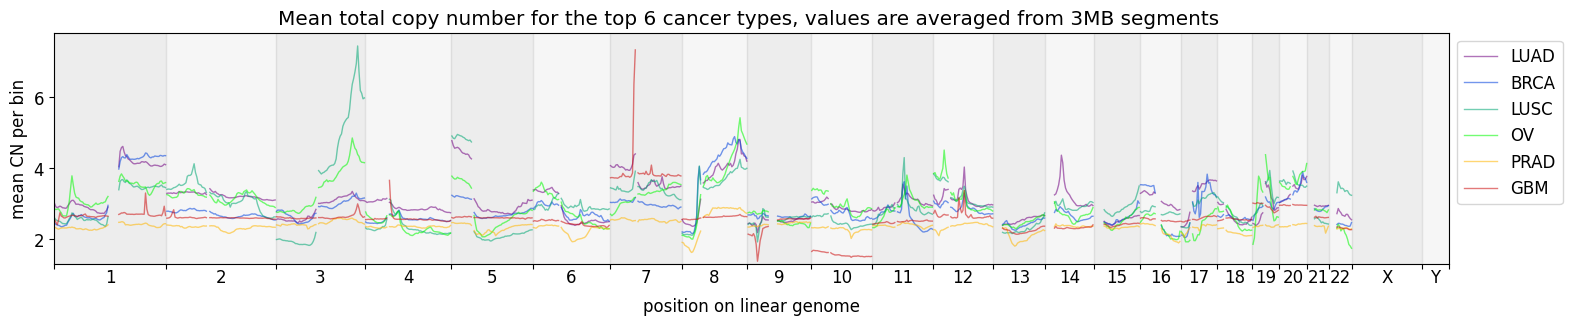

In [ ]:
# double font size
plt.rcParams["font.size"] = 12
fig_lines([only_aut(x) for x in top_6_cns_df], top_6, column="total_cn")
# add title
plt.title(f"Mean total copy number for the top 6 cancer types, values are averaged from {bin_size} segments ")

plt.savefig(f"{img_path}/top_6_profiles.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{img_path}/top_6_profiles.pdf", bbox_inches="tight")

C:\Users\adams\AppData\Local\Temp\ipykernel_17460\165816602.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True)).drop('type', axis=1).reset_index().set_index("sample_id")


(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

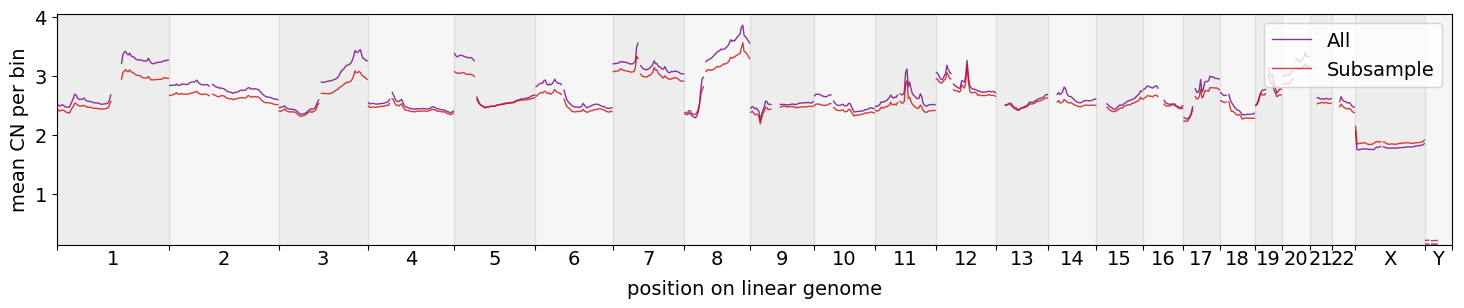

In [ ]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True)).drop('type', axis=1).reset_index().set_index("sample_id")
# select only 50 samples for each type to obtain balanced mean
selection = [sum_cns(group_bins(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn")